<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/24_Session_Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To understand the Conceptual Foundation of the Naive Bayes classifier, it is best to view it as a shift from the predictive mindset of linear regression to a probabilistic mindset. Here is a detailed breakdown of the three core pillars of this foundation.
1. **Classification vs. Regression:**

In linear regression, your goal was to predict a continuous numerical value (e.g., predicting the exact price of a house). With Naive Bayes, you are shifting to classification, where the goal is to assign a discrete "label" to an observation (e.g., "Spam" vs. "Not Spam," or "Healthy" vs. "Sick").

Instead of drawing a line to minimize error, you are essentially asking: "Given the evidence I see, what is the probability that this item belongs to Class A versus Class B?"

2. **The Naive Assumption:**

Naive Bayes is called "naive" because it makes a bold, simplifying assumption: it assumes that all features are conditionally independent of one another .

**What this means:** If you are classifying an email as "Spam," the model assumes that the presence of the word "Free" is independent of the presence of the word "Money."

**Why we do it:** In the real world, words or other features are often highly correlated. However, if we didn't assume they were independent, the math would become computationally impossible to solve for large datasets. By assuming independence, the model treats every piece of evidence as a separate, independent contributor to the final probability, which makes the computation lightning-fast.

3. **Bayes' Theorem:**

At the heart of the classifier is Bayes' Theorem, which provides a mathematical framework for updating our beliefs based on new evidence.
The formula is:

**P(A/B) = P(B/A) X P(A)  / P(B)**

To teach this effectively, break it down into these three intuitive components:

**The Prior P(A))**: This is our **starting belief**. Before we look at any specific evidence, how likely is it that an email is Spam? If 20% of all emails in your history are spam, your prior probability for "Spam" is 0.20.

**The Likelihood (P(B|A))**: This is the **evidence** stage. We ask, "If I know the email is spam,how likely is it to contain the word 'Winner'?".

**The Posterior (P(A|B))**: This is our **updated belief**: After looking at the evidence (the word "Winner"), this formula gives us the new, updated probability that the email is actually spam.

Naive Bayes essentially "learns" the distribution of the features for each class separately. It builds a mental model of what a "Spam" email looks like and what a "Ham" (non-spam) email looks like, and then compares a new email to both models to see which one it resembles more closely.


The Scenario: Patient Diagnosis

Imagine you are building a system to classify patients as having Flu or Healthy based on two symptoms:

"Fever" and "Cough".

**1. Classification vs. Regression:**

In linear regression, you might try to predict a patient's exact body temperature. Here, you are doing classification: you are sorting patients into one of two buckets: "Flu" or "Healthy". You aren't interested in the temperature value itself, but the probability that the patient belongs to the "Flu" class given their symptoms.

2. The "Naive" AssumptionIn our example, we assume that the presence of a "Fever" is independent of the presence of a "Cough" when we already know the patient has the Flu.

The Reality: In real life, these symptoms are often correlated; if you have a fever, you are more likely to have a cough.The "Naive" Simplification: We ignore that relationship. We treat "Fever" and "Cough" as separate, independent pieces of evidence. This allows us to multiply their probabilities together to reach a quick decision, even though the assumption is technically flawed.

3. Bayes’ Theorem in Action:We want to calculate the probability of the patient having the Flu given they have a Fever.


$$P(\text{Flu} | \text{Fever}) = \frac{P(\text{Fever} | \text{Flu}) \times P(\text{Flu})}{P(\text{Fever})}
$$The Prior ($P(\text{Flu})$): This is our "starting belief". If 10% of the population has the flu during this season, our prior probability is 0.10. We start with this belief before checking any symptoms.

The Likelihood ($P(\text{Fever} | \text{Flu})$): This is the "evidence" stage. We look at our records and ask: "If I know someone has the flu, how often do they have a fever?". Let’s say it's 80% (0.80).

The Posterior ($P(\text{Flu} | \text{Fever})$): This is our "updated belief". After observing the fever, we use the formula to update our initial 10% belief to a higher probability, helping us make a more informed diagnosis.

 **Mathematical Mechanics**

 Demystify how the classifier calculates its output.

The Decision Rule: Explain that the model calculates the probability of each class and selects the one with the highest value (Maximum A Posteriori).

Handling Features: Show how the formula scales when we have multiple features ($X_1, X_2, \dots$):$$P(\text{Class} | X_1, \dots, X_n) \propto P(\text{Class}) \prod_{i=1}^{n} P(X_i | \text{Class})$$Log-Probabilities: Explain why we use logs in practice—to prevent numerical underflow when multiplying many small probabilities together.

To explain the Mathematical Mechanics of Naive Bayes, it is essential to show how the model transforms from a single-feature probability into a powerful classifier that handles multiple pieces of evidence simultaneously.Building on the medical triage example, here is how the mechanics actually function under the hood.

1. **The Decision Rule:**

Maximum A Posteriori (MAP)Ultimately, our classifier has to make a choice: Is the patient "Flu" or "Healthy"? To do this, it calculates the posterior probability for every possible class and picks the one with the highest value. This is known as the Maximum A Posteriori (MAP) rule.$$\text{Predicted Class} = \arg \max_{c \in \{Flu, Healthy\}} P(c | \text{Fever, Cough})$$

2. **Scaling to Multiple Features:**

The real power of Naive Bayes appears when we have many features (e.g., Fever, Cough, Headache, Fatigue). The full Bayes' Theorem would require us to calculate the probability of all symptoms appearing together, which is statistically complex.Because of the "Naive" Assumption—that all symptoms are independent—we can simplify the calculation drastically. Instead of calculating one giant, complex probability, we multiply the individual probabilities of each symptom occurring for that specific class.

**The formula becomes:**

$$P(c | x_1, x_2, \dots, x_n) \propto P(c) \times P(x_1|c)
\times P(x_2|c) \times \dots \times P(x_n|c)$$$P(c)$: The Prior (how common the class is).$P(x_i|c)$: The Likelihood of each individual feature occurring given the class.

3. **Preventing Numerical Underflow (Log-Probabilities):**

In practice, if you have 100 features, you are multiplying 100 small probabilities (e.g., $0.01 \times 0.05 \times \dots$). Multiplying many numbers between 0 and 1 eventually leads to a result so tiny that computers struggle to represent it accurately (a problem called numerical underflow).To fix this, we use the Logarithm trick. Because logarithms turn multiplication into addition, we compute the sum of the logs instead:$$\log(P(c | X)) \propto \log(P(c)) + \sum_{i=1}^{n} \log(P(x_i | c))$$This keeps the numbers in a manageable range while preserving the ranking of the probabilities.

4. **The "Zero-Frequency" Problem & Laplace Smoothing:**

If your training data contains no instances of a patient having a "Headache" while having the "Flu," the likelihood $P(\text{Headache}|\text{Flu})$ becomes $0$. Because we are multiplying everything together, the entire probability becomes $0$, effectively "breaking" the model.We solve this using Laplace Smoothing (or "Add-one smoothing"), where we artificially add a small count to every feature to ensure no probability is ever zero:

$$P(x_i|c) = \frac{\text{count}(x_i, c) + 1}{\text{count}(c) + \text{total possible values}}$$

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/Seasonal influenza.csv')
print(df.head())
print(df.shape)

      season  date_code  weekending      region Respiratory_Virus  \
0  2009-2010     200940  10/10/2009    Bay Area       Influenza_A   
1  2009-2010     200940  10/10/2009    Bay Area       Influenza_B   
2  2009-2010     200940  10/10/2009    Bay Area   Total_Influenza   
3  2009-2010     200940  10/10/2009    Bay Area               RSV   
4  2009-2010     200940  10/10/2009  California       Influenza_A   

   Number_Positive  Specimens_Tested  Percent_Positive  
0               36               220             16.36  
1                0               220              0.00  
2               36               220             16.36  
3                0               190              0.00  
4             1077              3324             32.40  
(50011, 8)


In [ ]:
# 1 . check basic info and missing values

print(df.info())
print(df.isnull().sum())

df=df.sample(n=2000,random_state=42)
print(df)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50011 entries, 0 to 50010
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season             50011 non-null  object 
 1   date_code          50011 non-null  int64  
 2   weekending         50011 non-null  object 
 3   region             50011 non-null  object 
 4   Respiratory_Virus  50011 non-null  object 
 5   Number_Positive    50011 non-null  int64  
 6   Specimens_Tested   50011 non-null  int64  
 7   Percent_Positive   42414 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 3.1+ MB
None
season                  0
date_code               0
weekending              0
region                  0
Respiratory_Virus       0
Number_Positive         0
Specimens_Tested        0
Percent_Positive     7597
dtype: int64
          season  date_code weekending                region  \
20279  2015-2016     201624  6/18/2016        Lower Southern

In [ ]:
# Rename the column name as new assign name

df.columns = ['YEAR', 'CODE', 'WEEKENDING', 'LOCATION', 'VIRUS_TYPE',
              'NUMBER_POSITVE', 'TESTED_RESULT', 'PERCENT_POSITIVE']
print(df.columns)



Index(['YEAR', 'CODE', 'WEEKENDING', 'LOCATION', 'VIRUS_TYPE',
       'NUMBER_POSITVE', 'TESTED_RESULT', 'PERCENT_POSITIVE'],
      dtype='object')


In [ ]:
# Target the 'VIRUS_TYPE'
print(df['VIRUS_TYPE'])


20279                          RSV
33054            Total_Coronavirus
40476                          RSV
47955              Parainfluenza_3
49802                  Influenza_A
                   ...            
34962          Total_Parainfluenza
20779      Coronavirus_UnknownType
15085       Enterovirus_Rhinovirus
13154    Parainfluenza_UnknownType
34983                  Influenza_B
Name: VIRUS_TYPE, Length: 2000, dtype: object


In [ ]:
for i, col in enumerate(df.columns):
    print(f'Index {i}: {col}')

Index 0: YEAR
Index 1: CODE
Index 2: WEEKENDING
Index 3: LOCATION
Index 4: VIRUS_TYPE
Index 5: NUMBER_POSITVE
Index 6: TESTED_RESULT
Index 7: PERCENT_POSITIVE


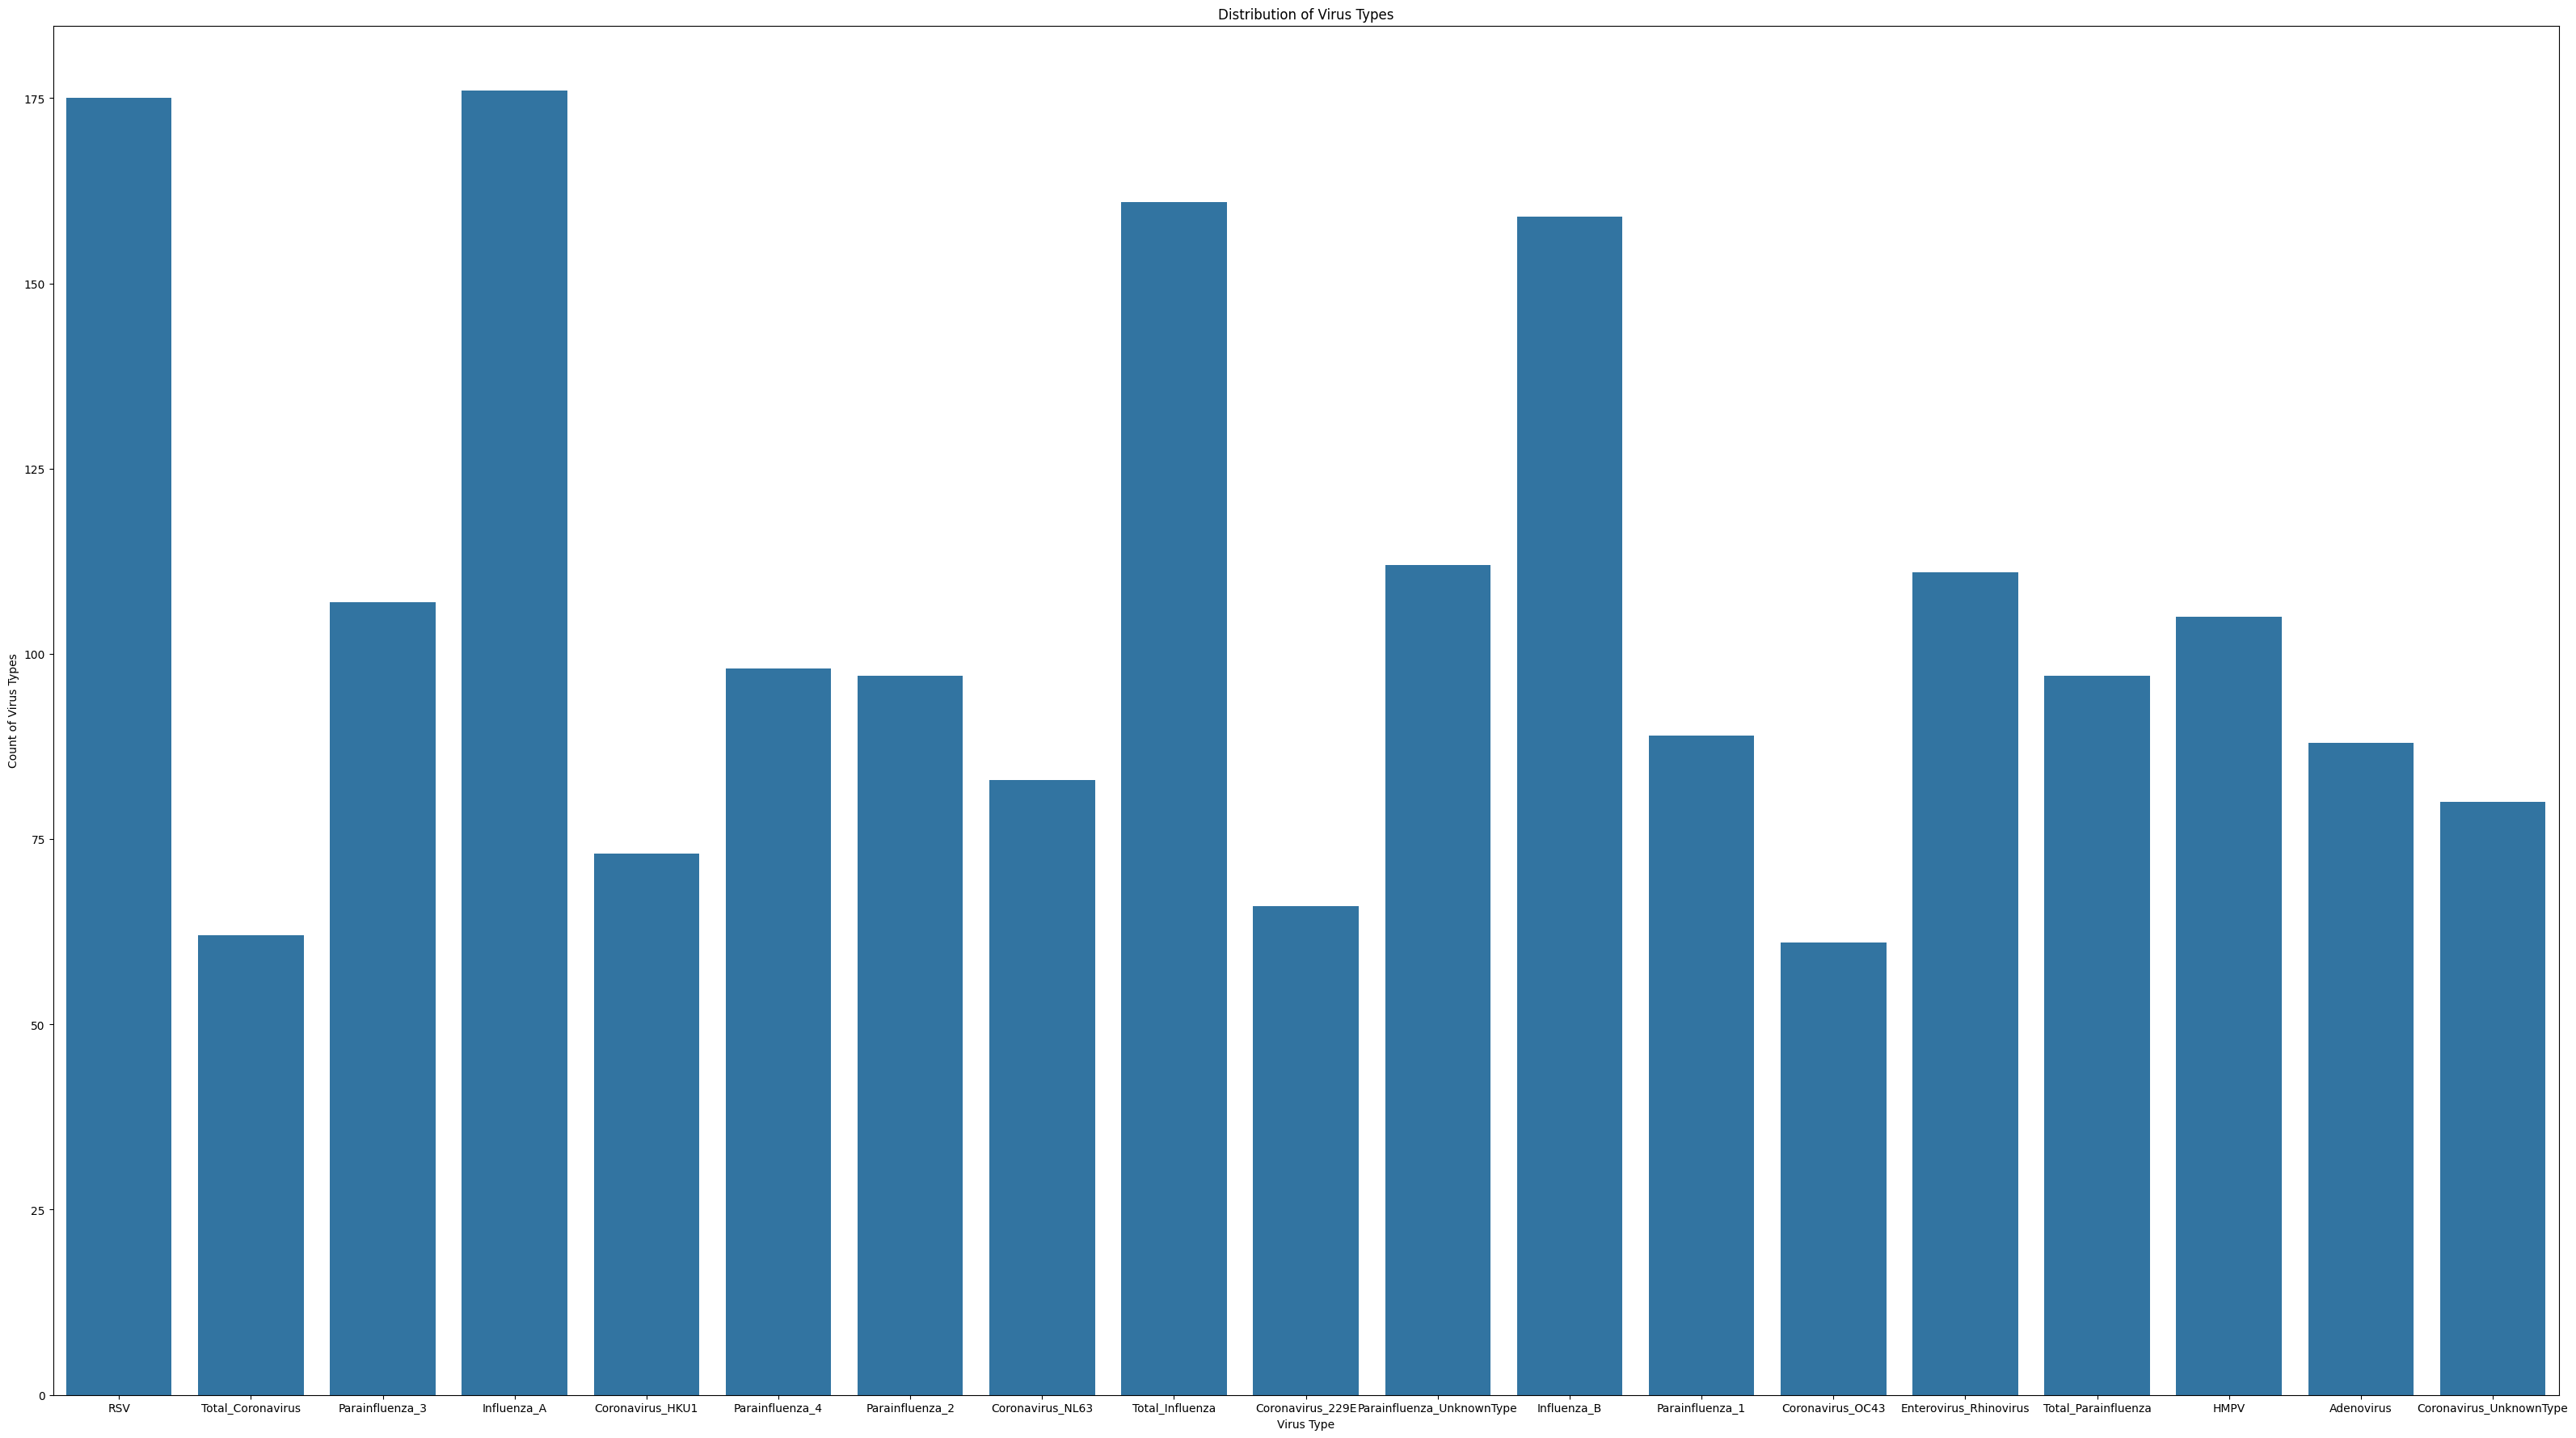

In [ ]:
plt.figure(figsize=(40,22))
sns.countplot(x='VIRUS_TYPE',data=df)
plt.title('Distribution of Virus Types')
plt.xlabel('Virus Type')
plt.ylabel('Count of Virus Types')
plt.show()

In [ ]:
# Target variable is now 'VIRUS_TYPE'

y = df['VIRUS_TYPE']

# Features (X) are everything except 'Type'
X = df.drop(columns=['VIRUS_TYPE'])

# print(X)
print(y.tail(50))


8297                           RSV
949                    Influenza_B
13013                  Influenza_A
26302                          RSV
37752              Parainfluenza_3
38028             Coronavirus_NL63
5936               Parainfluenza_2
43374              Parainfluenza_1
43678              Parainfluenza_1
24261              Parainfluenza_2
10927              Parainfluenza_1
37989             Coronavirus_HKU1
46788             Coronavirus_OC43
15978              Parainfluenza_3
32435          Total_Parainfluenza
18289             Coronavirus_229E
47159    Parainfluenza_UnknownType
49815              Parainfluenza_1
34688            Total_Coronavirus
15889              Total_Influenza
40303                  Influenza_B
33018                         HMPV
32541            Total_Coronavirus
49040    Parainfluenza_UnknownType
5071                           RSV
25588       Enterovirus_Rhinovirus
8962        Enterovirus_Rhinovirus
3001                   Influenza_B
30061               

**Step 2: Symptom-Disease Frequency:**

Since Naive Bayes relies on the probability of a feature occurring given a class ($P(X|C)$), visualizing this frequency is crucial. This helps students "see" the likelihoods before the algorithm calculates them.

<Figure size 4000x2200 with 0 Axes>

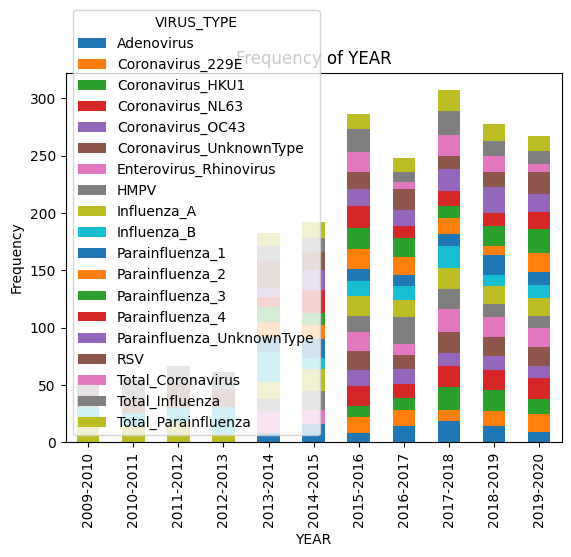

<Figure size 4000x2200 with 0 Axes>

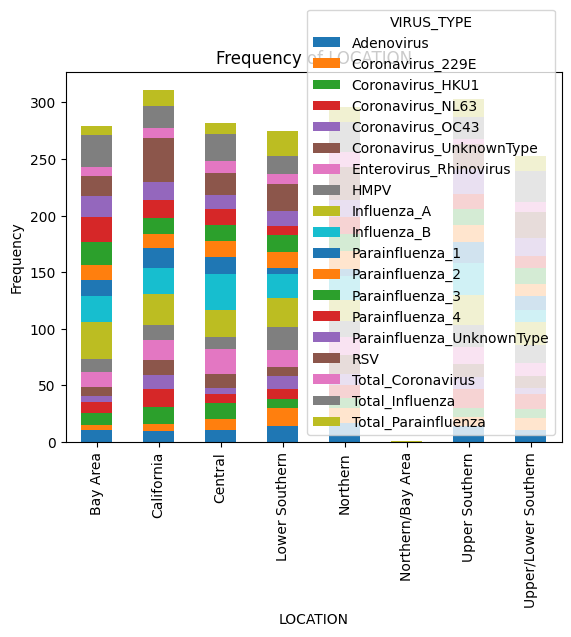

<Figure size 4000x2200 with 0 Axes>

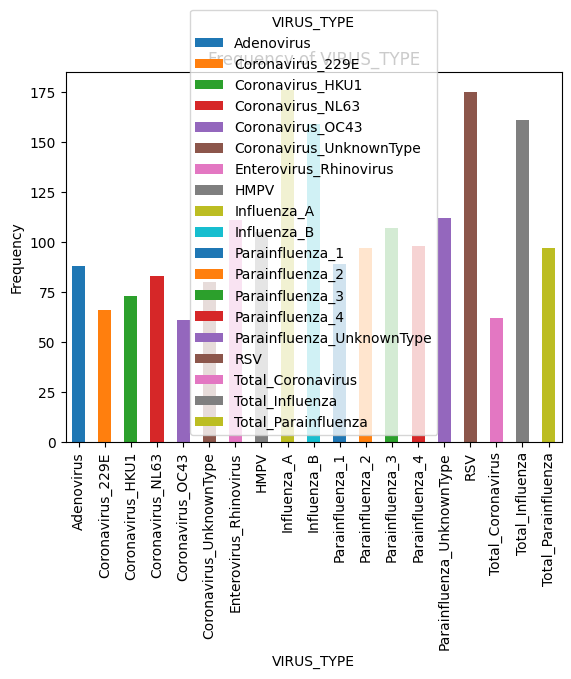

In [ ]:
for symptom_col in ['YEAR', 'LOCATION', 'VIRUS_TYPE']:
    plt.figure(figsize=(40,22))
    pd.crosstab(df[symptom_col],df['VIRUS_TYPE']).plot(kind='bar',stacked=True)
    plt.title(f'Frequency of {symptom_col}')
    plt.xlabel(symptom_col)
    plt.ylabel('Frequency')
    plt.show()

**Step 3: Checking for Feature Independence**

While Naive Bayes assumes independence, real-world data is correlated. It is an industry standard to check for high correlations, as these might require feature selection.


Before running the heatmap, you must either drop the non-numeric column . Since we are building Naive Bayes, this is a great step to demonstrate Feature Selection.

         CODE  NUMBER_POSITVE  TESTED_RESULT  PERCENT_POSITIVE
20279  201624               0             78              0.00
33054  201816               1             70              1.43
40476  201920               1            102              0.98
47955  202024               0             40              0.00
49802  202038               0             57              0.00
...       ...             ...            ...               ...
34962  201830              15            211              7.11
20779  201628               0            215              0.00
15085  201536             175            747             23.43
13154  201514               0            338              0.00
34983  201831               0            153              0.00

[2000 rows x 4 columns]


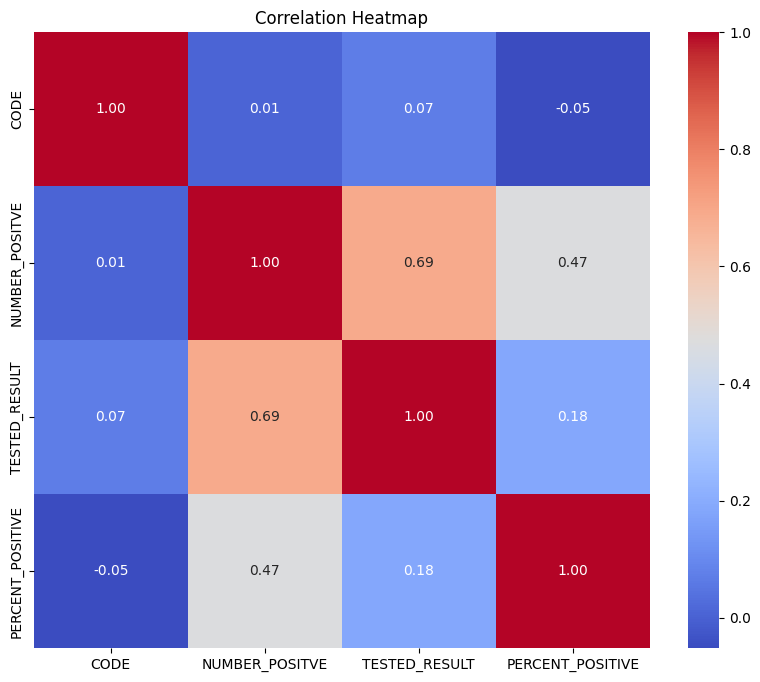

In [ ]:
# Use a correlation heatmap for binary/numeric features
# Calculate correlation only on numeric columns
# We drop 'Type' because it is a string
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, square=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Distribution Analysis**

If you decide to use Gaussian Naive Bayes later, you must check if your continuous features are normally distributed.

In [ ]:
# print all colummn names to see what you are working with

print(df.columns.tolist())


['YEAR', 'CODE', 'WEEKENDING', 'LOCATION', 'VIRUS_TYPE', 'NUMBER_POSITVE', 'TESTED_RESULT', 'PERCENT_POSITIVE']


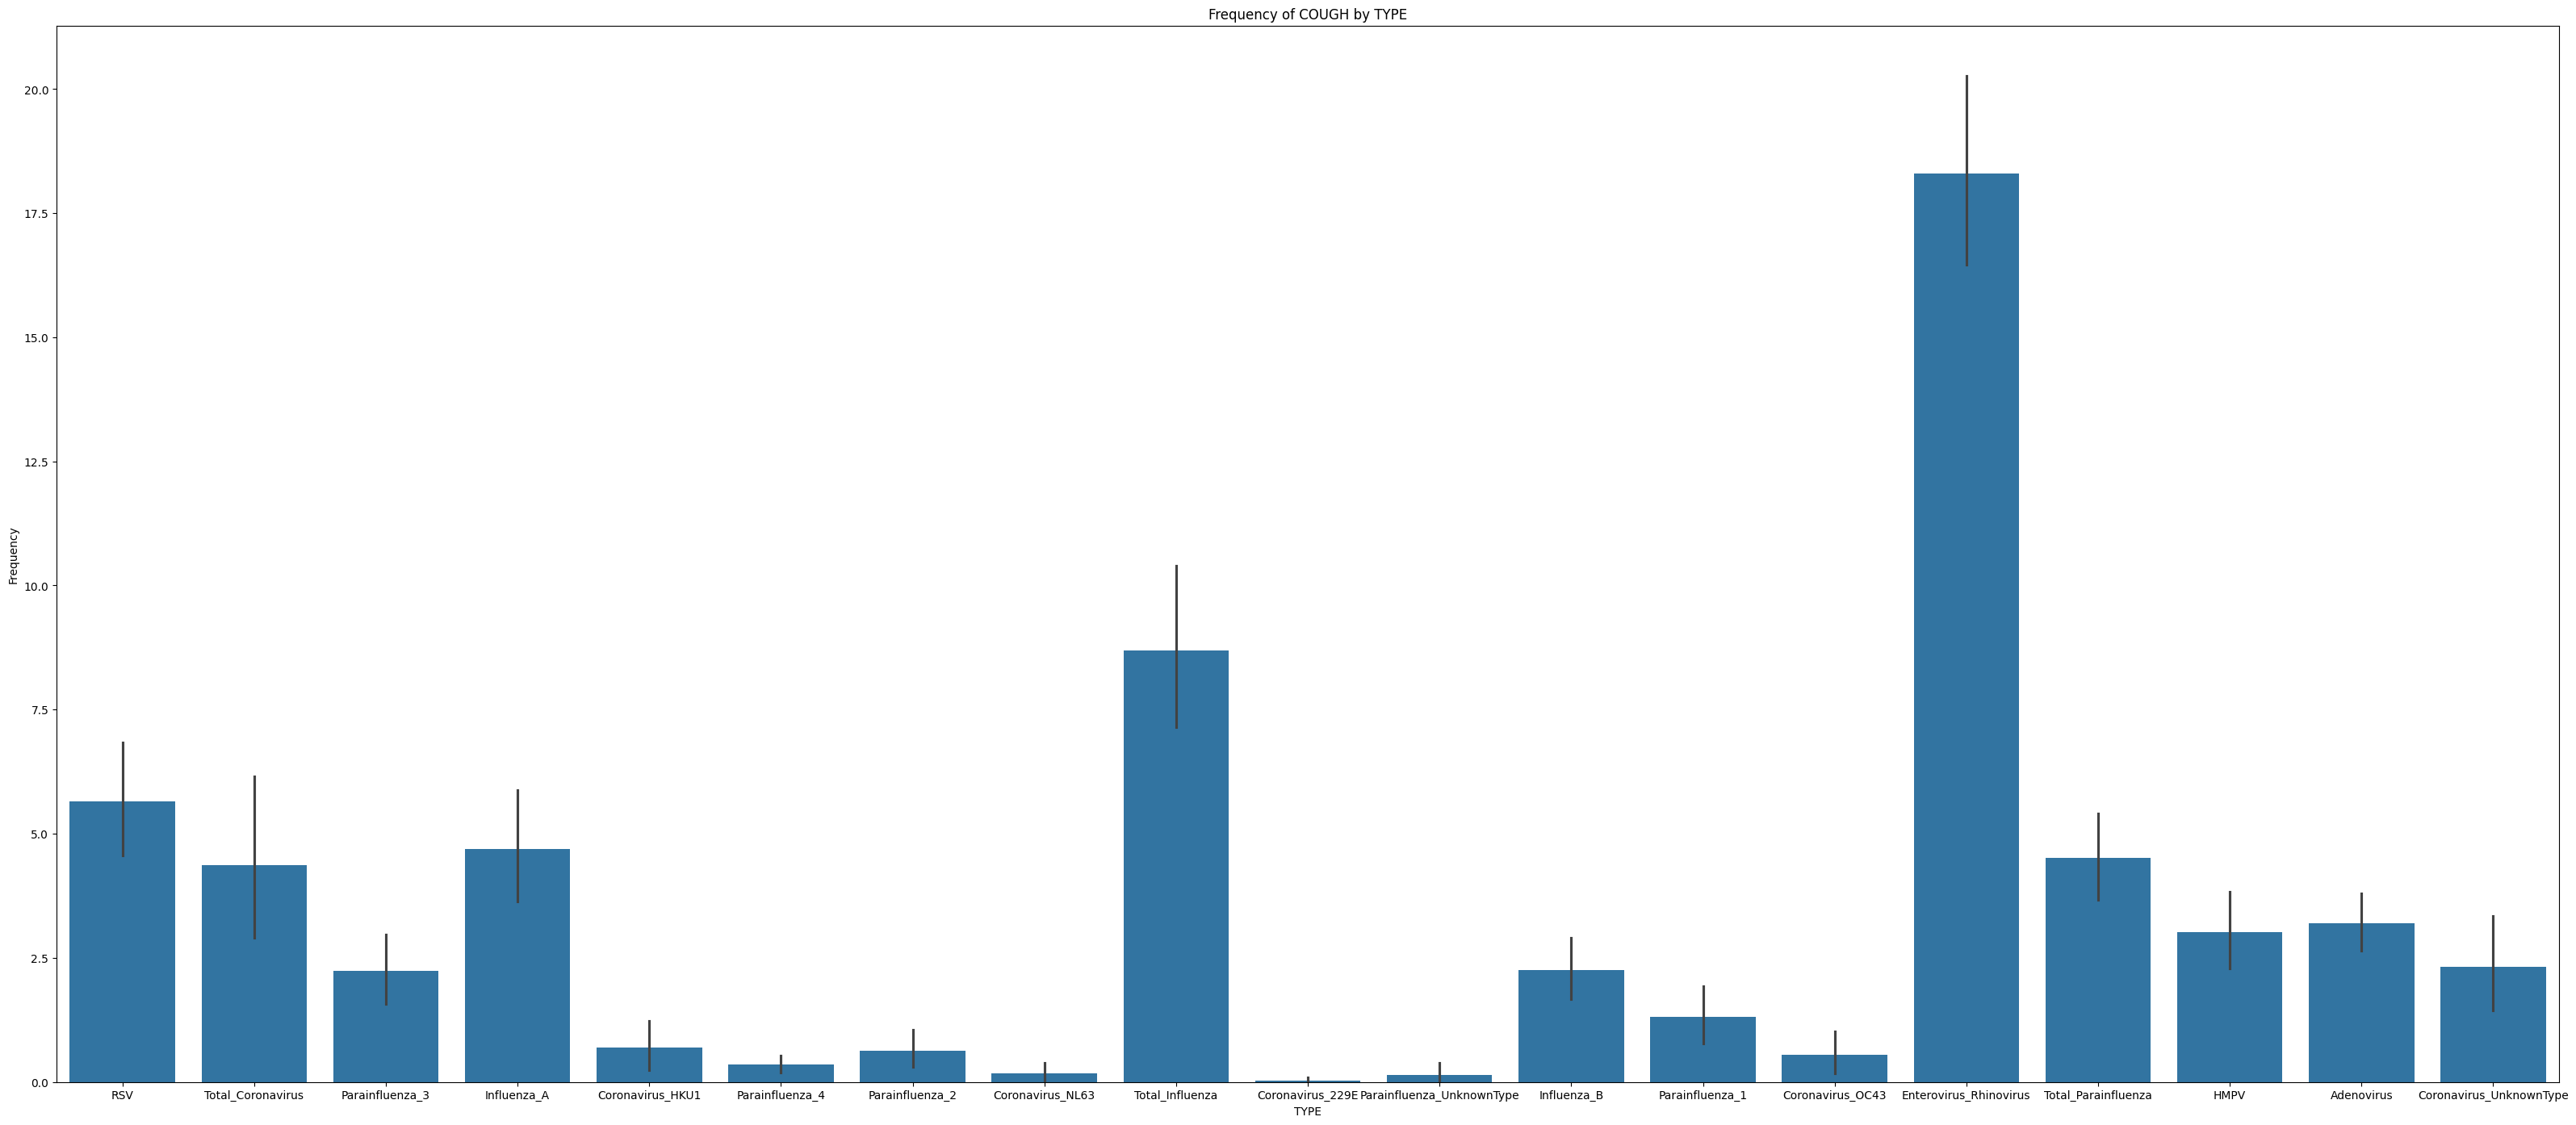

In [ ]:
# Let's look at the frequency of a symptom(e.g., "COUGH") by "TYPE"

plt.figure(figsize=(40,17))
sns.barplot(data=df, x='VIRUS_TYPE', y='PERCENT_POSITIVE')
plt.title('Frequency of COUGH by TYPE')
plt.xlabel('TYPE')
plt.ylabel('Frequency')
plt.show()

**Data Preprocessing**

Our dataset contains symptom data (mostly binary flags) and a target category, the preprocessing stage is focused on preparing features for a probabilistic model like Naive Bayes.

Because our  data is likely already numeric (0s and 1s), the preprocessing is much simpler than handling text or missing values. However, you must always ensure the data is split properly to prevent data leakage.

Preprocessing Pipeline
This code covers:

Splitting the data: Essential to prevent the model from "cheating" by seeing the test data during training.

Feature/Target Separation: Isolate the symptoms from the label.

Encoding: Ensure the target TYPE is numeric (if it isn't already).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop rows with any NaN values from the dataframe before splitting
df_cleaned = df.dropna()

# 1. Separate feature (X) and target (y)
# Drop 'VIRUS_TYPE' and other non-numeric string columns
X = df_cleaned.drop(columns=['VIRUS_TYPE', 'YEAR', 'WEEKENDING', 'LOCATION'])
y = df_cleaned['VIRUS_TYPE']

# 2. Encode the target (if 'TYPE' contains strings like 'FLU','Cold')

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(y_encoded)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f'Testing shape: {X_test.shape}')
print(f'Training shape: {X_train.shape}')

[15 16 15 ...  6 14  9]
Testing shape: (343, 4)
Training shape: (1368, 4)


In [ ]:
from sklearn.naive_bayes import BernoulliNB

# Gaussian NB,

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = BernoulliNB()
# 2. Train the model
model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = model.predict(X_test)
print(y_pred)
# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')


[15 15 14 14 15 15 15 15 14 14 15 15 15 15 14 15 14 15 15 15 14 14 14 15
 15 15 14 15 14 15 15 15 15 14 15 14 15 14 14 14 15 15 15 14 15 15 15 15
 14 15 15 14 14 14 14 15 15 14 15 15 14 14 15 14 15 15 15 15 14 14 14 15
 15 15 15 14 15 14 14 14 15 15 15 14 15 15 14 15 14 14 15 15 14 15 15 14
 15 14 14 15 14 15 14 14 14 14 14 15 15 15 14 14 15 14 15 14 15 15 15 14
 15 15 14 14 14 14 15 15 14 14 15 14 15 15 15 15 14 14 15 15 14 15 15 15
 14 14 14 14 15 15 15 15 15 14 15 14 14 15 14 15 15 15 14 14 14 15 15 14
 15 15 14 14 14 15 14 14 14 15 15 14 15 15 15 15 15 14 15 14 14 14 14 15
 15 14 15 15 15 14 14 15 15 15 15 14 14 14 15 14 14 15 15 15 15 15 14 15
 15 15 14 14 14 14 14 15 14 15 15 14 14 15 15 15 15 15 15 14 15 15 14 14
 15 14 15 15 14 15 15 15 15 15 14 15 15 15 14 15 15 15 15 15 14 14 15 15
 14 15 15 15 15 15 14 14 15 15 15 15 15 15 15 15 15 15 14 15 15 15 15 15
 14 15 15 15 15 14 15 14 15 14 14 15 14 14 15 15 14 14 15 15 15 15 14 14
 15 14 14 15 14 15 14 14 15 15 15 15 15 14 15 14 15

# **Model Evaluation**



Accuracy Score: 0.119533527696793

 Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        11
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00        20
           7       0.00      0.00      0.00        19
           8       0.00      0.00      0.00        33
           9       0.00      0.00      0.00        30
          10       0.00      0.00      0.00        17
          11       0.00      0.00      0.00        18
          12       0.00      0.00      0.00        19
          13       0.00      0.00      0.00        19
          14       0.14      0.95      0.25        21
          15       0.10      0.66      0.18        32
          16       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


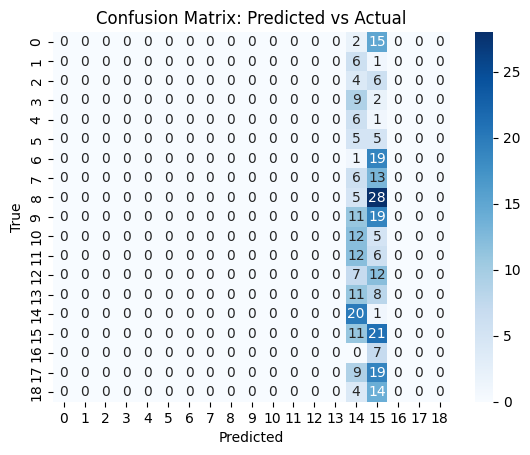

In [ ]:
# 1. Performance Summary

print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('\n Classification Report:\n', classification_report(y_test, y_pred))
print('\n Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

# 2. Visualize the confusion Matrix
# This helps students see where the model is confusing one disease for another

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()